 Load the cleaned data and set up features

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import matplotlib.pyplot as plt
import pickle
import os

df = pd.read_csv('data/diabetes_cleaned.csv')

# Only use numeric features for the model
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[features]
y = df['Outcome']

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features shape: (768, 8)
Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


Step 2 — Split into train and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% held back for testing
    random_state=42,      # makes results reproducible
    stratify=y            # keeps diabetic ratio the same in both splits
)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))
print("\nDiabetic % in train:", f"{y_train.mean():.1%}")
print("Diabetic % in test: ", f"{y_test.mean():.1%}")

#Scaling makes all features sit on the same numeric range so no single feature dominates just because its numbers are bigger (e.g. Insulin values are in the hundreds, while Pregnancies is 0–17).

Training rows: 614
Testing rows:  154

Diabetic % in train: 34.9%
Diabetic % in test:  35.1%


Step 3 — Scale the features

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print("Example — first row before scaling:", X_train.iloc[0].values)
print("Example — first row after scaling: ", X_train_scaled[0].round(2))

Scaling done.
Example — first row before scaling: [ 1.   90.   62.   12.   43.   27.2   0.58 24.  ]
Example — first row after scaling:  [-0.85 -1.06 -0.83 -1.92 -1.2  -0.77  0.31 -0.79]


Step 4 — Train the XGBoost model

In [4]:
model = xgb.XGBClassifier(
    n_estimators=100,      # number of trees
    max_depth=4,           # how deep each tree can grow
    learning_rate=0.1,     # how fast the model learns
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train_scaled, y_train)
print("Model trained successfully!")

Model trained successfully!


Step 5 — Evaluate the model

In [5]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

ROC-AUC Score: 0.8230

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.83      0.80       100
    Diabetes       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



Cell 6 — Plot the confusion matrix:

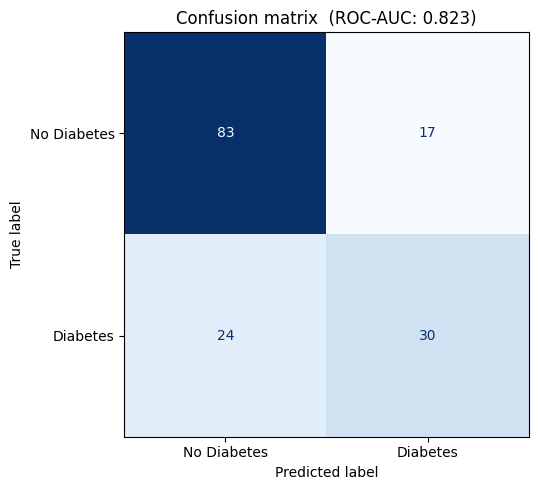

Chart saved!


In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Diabetes', 'Diabetes'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion matrix  (ROC-AUC: {roc_auc:.3f})')
plt.tight_layout()
plt.savefig('charts/confusion_matrix.png')
plt.show()
print("Chart saved!")

Step 6 — Plot feature importance

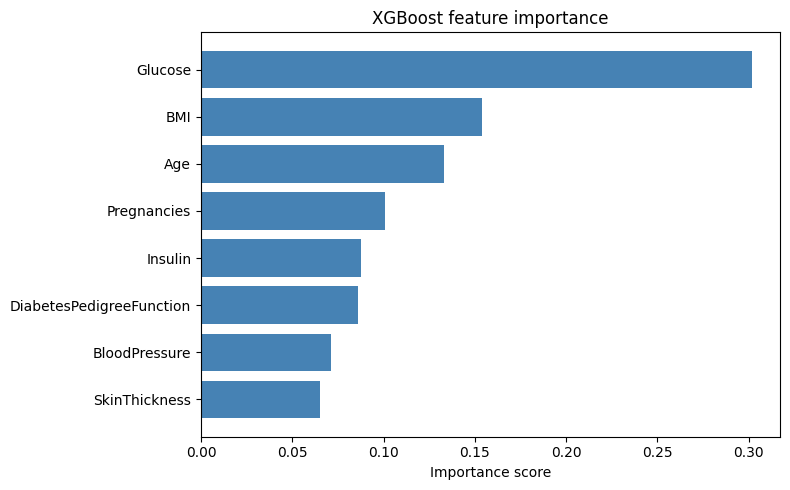

Chart saved!


In [9]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('XGBoost feature importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('charts/feature_importance.png')
plt.show()
print("Chart saved!")

In [11]:
os.makedirs('../model', exist_ok=True)

pickle.dump(model,  open('model/xgb_model.pkl', 'wb'))
pickle.dump(scaler, open('model/scaler.pkl', 'wb'))

print("Model saved to  ../model/xgb_model.pkl")
print("Scaler saved to ../model/scaler.pkl")

Model saved to  ../model/xgb_model.pkl
Scaler saved to ../model/scaler.pkl
